# FCNN - Bengaluru House Price Prediction
نسخة مطبّقة من نفس منهجية نوت بوك الـ Concrete (FCNN + Evaluation) على بيانات أسعار شقق بنغالورو.

**ملاحظة عن التكييف:** الداتا سيت الأصلية فيها أعمدة نصية (زي `size` و `total_sqft`) مش أرقام جاهزة زي داتا الخرسانة، فتم عمل تنظيف بسيط لتحويلها لأرقام قبل تطبيق نفس خطوات الـ scaling والـ FCNN والـ evaluation.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
Data = pd.read_csv('bengaluru_house_prices.csv')
Data.head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [3]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


## تنظيف الأعمدة النصية
- `size` -> استخراج عدد الغرف (BHK) كرقم
- `total_sqft` -> بعض القيم مكتوبة كمدى (مثال: '2100 - 2850') فتم أخذ المتوسط، والقيم الغريبة تحولت إلى NaN
- `area_type` -> عمل One-Hot Encoding لأنه عدد فئاته قليل (4 فئات)
- تم حذف `location`, `society`, `availability` لأن عدد الفئات فيها كبير جدًا (High Cardinality) وغير مناسب للتعامل المباشر بنفس أسلوب النوت بوك الأصلي
- تم حذف الصفوف الناقصة (NaN) بعد التنظيف

In [4]:
df = Data.copy()

# استخراج عدد الغرف من عمود size
df['BHK'] = df['size'].str.split(' ').str[0]
df['BHK'] = pd.to_numeric(df['BHK'], errors='coerce')

# تحويل total_sqft لرقم (بما فيها المدى مثل '2100 - 2850')
def convert_sqft(x):
    try:
        return float(x)
    except:
        pass
    tokens = str(x).split('-')
    if len(tokens) == 2:
        try:
            return (float(tokens[0]) + float(tokens[1])) / 2
        except:
            return np.nan
    return np.nan

df['total_sqft_num'] = df['total_sqft'].apply(convert_sqft)

# One-Hot Encoding لـ area_type
area_dummies = pd.get_dummies(df['area_type'], prefix='area', drop_first=True)

HDNames = ['total_sqft_num', 'bath', 'balcony', 'BHK'] + list(area_dummies.columns) + ['price']

Data = pd.concat([
    df[['total_sqft_num', 'bath', 'balcony', 'BHK']],
    area_dummies,
    df[['price']]
], axis=1)

Data = Data.dropna().astype(float)
Data.columns = HDNames
Data.head(20)

,total_sqft_num,bath,balcony,BHK,area_Carpet Area,area_Plot Area,area_Super built-up Area,price
0,1056.0,2.0,1.0,2.0,0.0,0.0,1.0,39.07
1,2600.0,5.0,3.0,4.0,0.0,1.0,0.0,120.00
2,1440.0,2.0,3.0,3.0,0.0,0.0,0.0,62.00
3,1521.0,3.0,1.0,3.0,0.0,0.0,1.0,95.00
4,1200.0,2.0,1.0,2.0,0.0,0.0,1.0,51.00
5,1170.0,2.0,1.0,2.0,0.0,0.0,1.0,38.00
8,1310.0,3.0,1.0,3.0,0.0,0.0,1.0,63.25
10,1800.0,2.0,2.0,3.0,0.0,0.0,1.0,70.00
11,2785.0,5.0,3.0,4.0,0.0,1.0,0.0,295.00
12,1000.0,2.0,1.0,2.0,0.0,0.0,1.0,38.00


In [5]:
summary = Data.describe()
print(summary)

       total_sqft_num          bath       balcony           BHK  \
count    12669.000000  12669.000000  12669.000000  12669.000000   
mean      1511.842126      2.616308      1.585682      2.736443   
std       1162.051672      1.223838      0.816734      1.202598   
min          5.000000      1.000000      0.000000      1.000000   
25%       1100.000000      2.000000      1.000000      2.000000   
50%       1260.000000      2.000000      2.000000      3.000000   
75%       1640.000000      3.000000      2.000000      3.000000   
max      52272.000000     40.000000      3.000000     43.000000   

       area_Carpet  Area  area_Plot  Area  area_Super built-up  Area  \
count       12669.000000     12669.000000               12669.000000   
mean            0.006394         0.143579                   0.668798   
std             0.079707         0.350676                   0.470664   
min             0.000000         0.000000                   0.000000   
25%             0.000000         0.0

# boxplot is a graphical representation used to describe the distribution of a sample by simple dispersion and position indexes

<Axes: >

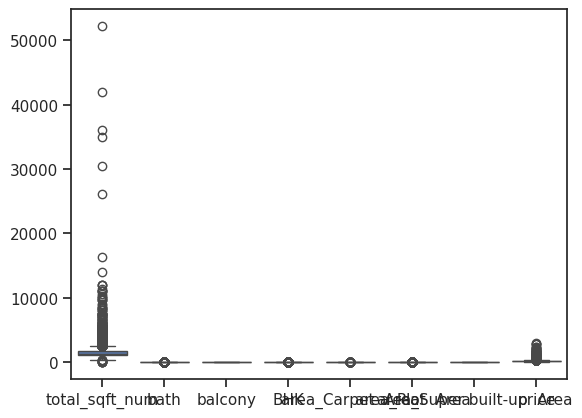

In [6]:
sns.set(style="ticks")
sns.boxplot(data=Data)

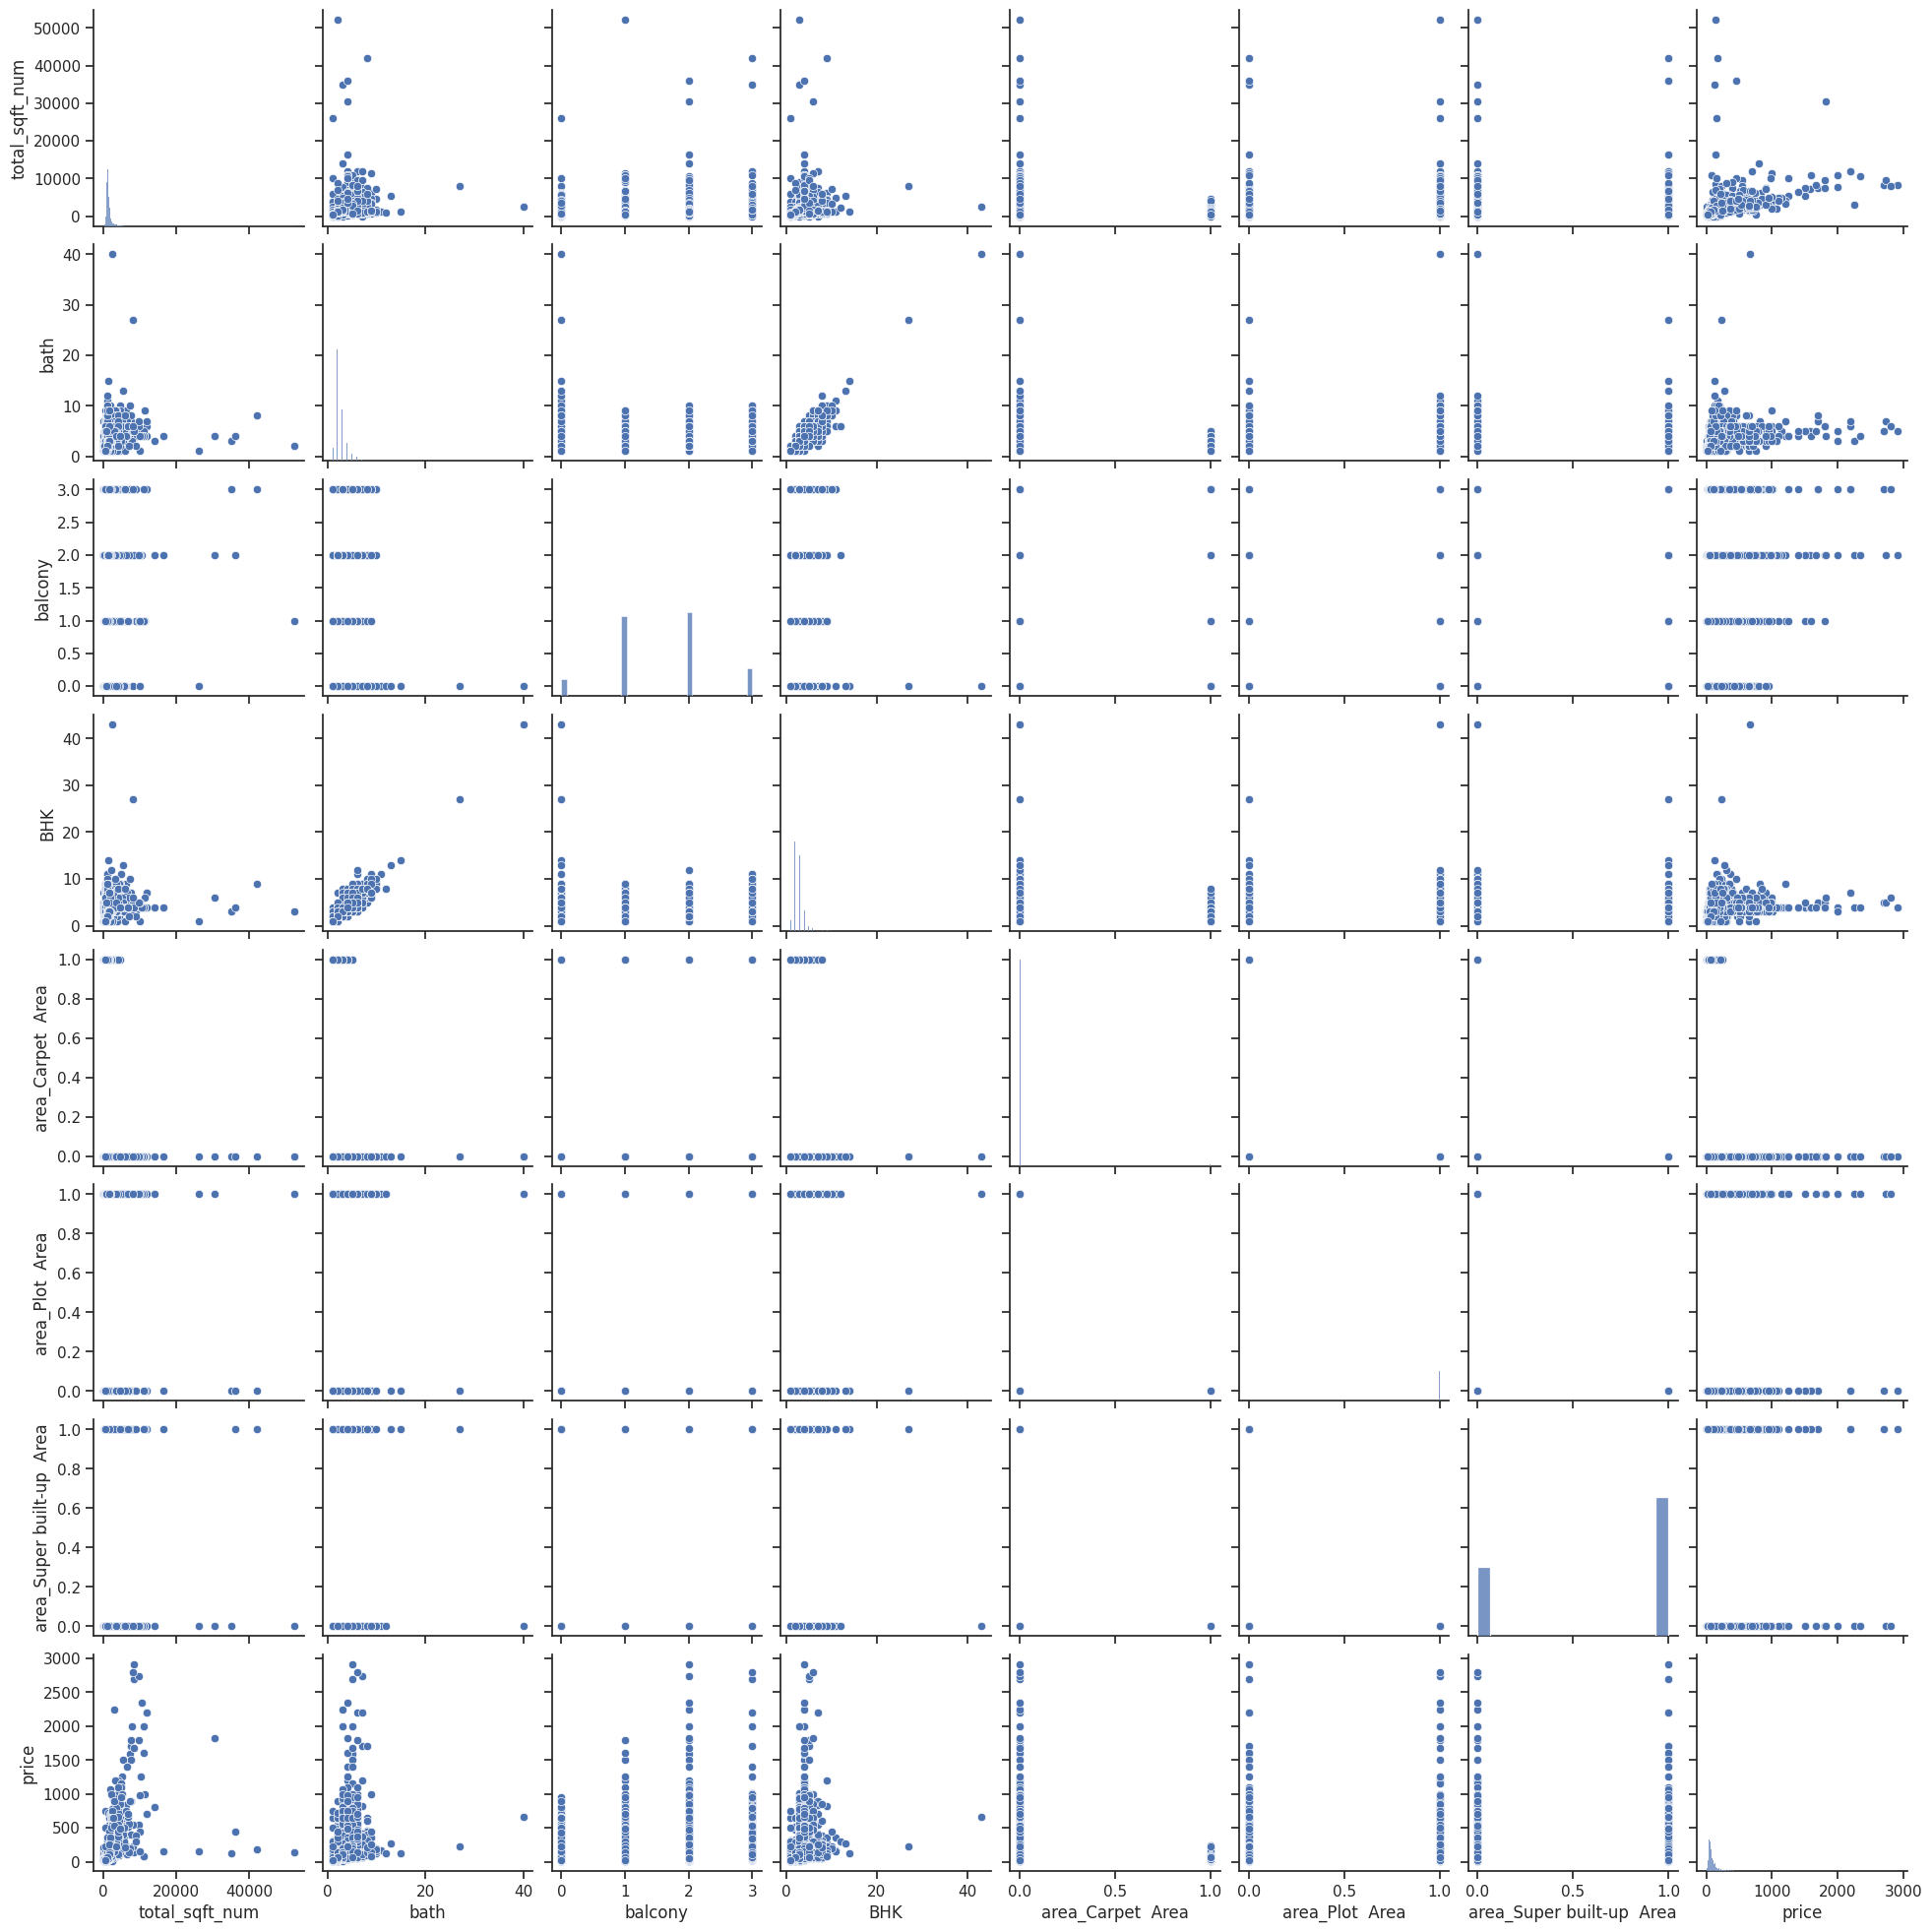

In [7]:
sns.pairplot(data=Data)

x(scaled) = (x-x(min)/(x(max)-x(min)))

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
print(scaler.fit(Data))

MinMaxScaler()


In [9]:
DataScaled = scaler.fit_transform(Data)
DataScaled = pd.DataFrame(DataScaled, columns=HDNames)

In [10]:
summary = DataScaled.describe()
print(summary)

       total_sqft_num          bath       balcony           BHK  \
count    12669.000000  12669.000000  12669.000000  12669.000000   
mean         0.028830      0.041444      0.528561      0.041344   
std          0.022233      0.031380      0.272245      0.028633   
min          0.000000      0.000000      0.000000      0.000000   
25%          0.020950      0.025641      0.333333      0.023810   
50%          0.024011      0.025641      0.666667      0.047619   
75%          0.031282      0.051282      0.666667      0.047619   
max          1.000000      1.000000      1.000000      1.000000   

       area_Carpet  Area  area_Plot  Area  area_Super built-up  Area  \
count       12669.000000     12669.000000               12669.000000   
mean            0.006394         0.143579                   0.668798   
std             0.079707         0.350676                   0.470664   
min             0.000000         0.000000                   0.000000   
25%             0.000000         0.0

<Axes: >

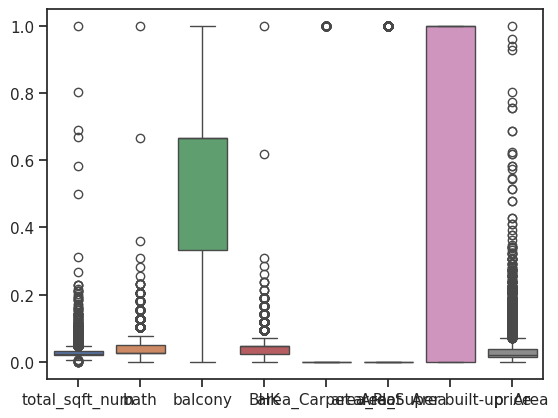

In [11]:
sns.boxplot(data=DataScaled)

In [12]:
from sklearn.model_selection import train_test_split
n_features = len(HDNames) - 1
Predictors = pd.DataFrame(DataScaled.iloc[:, :n_features])
Response = pd.DataFrame(DataScaled.iloc[:, n_features])

In [13]:
Pred_train, Pred_test, Resp_train, Resp_test = train_test_split(Predictors, Response, test_size=0.2, random_state=1) #20% من الداتا يتقسم كـ test data

print(Pred_train.shape)
print(Pred_test.shape)
print(Resp_train.shape)
print(Resp_test.shape)

(10135, 7)
(2534, 7)
(10135, 1)
(2534, 1)


1. Import the Sequential from keras.models
1. Stack layers using the .add() method
2. Configure the learning process using .compile() method
2. Train the model on train dataset using .fit() method

In [14]:
from keras.models import Sequential, Model
from keras.layers import Dense, BatchNormalization, Dropout, Input
from keras.optimizers import Adam, SGD, RMSprop

# fully connected neural network with 4 levels (2 hidden layers)
model = Sequential()

model.add(Input(shape=(n_features,)))
model.add(Dense(20, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))

I0000 00:00:1786564777.397913    1591 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786564777.398593    1591 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786564777.460450    1591 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786564778.953664    1591 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786564778.954136    1591 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1786564779.206830    1591 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

1. adam optimizer: خوارزمية تحسين قائمة على الـ gradient بمعدل تعلم تكيفي
2. mean_squared_error loss function: متوسط مربع الفرق بين القيمة الحقيقية والمتوقعة
1. mae metric: متوسط الخطأ المطلق، استُبدل بدل accuracy لأن هذه مسألة انحدار (regression) وليست تصنيف، و accuracy مش مقياس منطقي لمشكلة تنبؤ بقيمة مستمرة زي السعر

In [17]:
history = model.fit(Pred_train, Resp_train, epochs=100, verbose=1, validation_split=0.2, batch_size=128)

Epoch 1/100


 1/64 ━━━━━━━━━━━━━━━━━━━━ 1:33 1s/step - loss: 0.0244 - mae: 0.0944

32/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0074 - mae: 0.0469 

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0050 - mae: 0.0369

64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0050 - mae: 0.0369 - val_loss: 0.0014 - val_mae: 0.0215


...

Epoch 100/100


 1/64 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 5.7215e-04 - mae: 0.0116

30/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.5144e-04 - mae: 0.0124  

61/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1322e-04 - mae: 0.0127

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9029e-04 - mae: 0.0126 - val_loss: 7.6035e-04 - val_mae: 0.0120


Calculate the coefficient of determination (R-squared)

* R-squared يقيس مدى قدرة النموذج على التنبؤ بالبيانات، وقيمته بين 0 و 1؛ كلما اقتربت من 1 كلما كان النموذج أفضل

In [18]:
from sklearn.metrics import r2_score
y_predKM = model.predict(Pred_test)
print('Coefficient of determination of Keras Model')
print(r2_score(Resp_test, y_predKM))

 1/80 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step

52/80 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Coefficient of determination of Keras Model
0.6089022159576416


Outlier distort data analysis result

---
We will use Tukey's method which will use the interquartile range (IQR) approach

---

In [19]:
Q1 = DataScaled.quantile(0.25)
Q3 = DataScaled.quantile(0.75)
IQR = Q3-Q1
print(IQR)

total_sqft_num               0.010332
bath                         0.025641
balcony                      0.333333
BHK                          0.023810
area_Carpet  Area            0.000000
area_Plot  Area              0.000000
area_Super built-up  Area    1.000000
price                        0.022720
dtype: float64


In [20]:
DataScaledOut = DataScaled[~((DataScaled < (Q1 - 1.5 * IQR)) | (DataScaled > (Q3 + 1.5 * IQR))).any(axis=1)]
DataScaledOut.shape

(9742, 8)

Text(0.5, 1.0, 'Data without outliers')

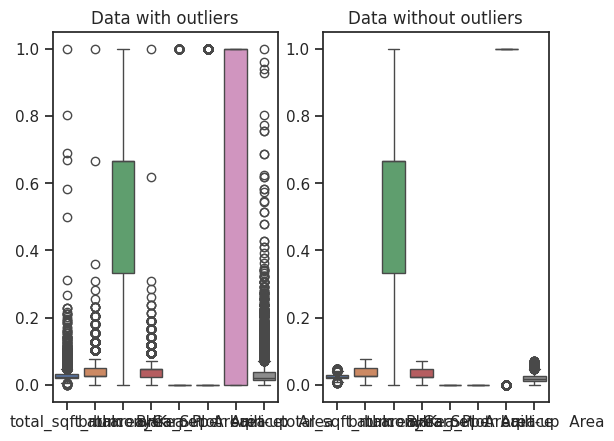

In [21]:
plt.figure(1)
plt.subplot(121)
sns.boxplot(data=DataScaled)
plt.title("Data with outliers")

plt.subplot(122)
sns.boxplot(data=DataScaledOut)
plt.title("Data without outliers")

In [22]:
Predictors2 = pd.DataFrame(DataScaledOut.iloc[:, :n_features])
Response2 = pd.DataFrame(DataScaledOut.iloc[:, n_features])

In [23]:
Pred_train2, Pred_test2, Resp_train2, Resp_test2 = train_test_split(Predictors2, Response2, test_size=0.2, random_state=1)
print(Pred_train2.shape)
print(Pred_test2.shape)
print(Resp_train2.shape)
print(Resp_test2.shape)

(7793, 7)
(1949, 7)
(7793, 1)
(1949, 1)


In [24]:
# fully connected neural network with 4 levels (2 hidden layers) - بدون outliers
model2 = Sequential()
model2.add(Input(shape=(n_features,)))
model2.add(Dense(20, activation='relu'))
model2.add(Dense(10, activation='relu'))
model2.add(Dense(10, activation='relu'))
model2.add(Dense(1, activation='linear'))

In [25]:
model2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [26]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 20)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model2.fit(Pred_train2, Resp_train2, epochs=100, verbose=1)

Epoch 1/100


  1/244 ━━━━━━━━━━━━━━━━━━━━ 4:26 1s/step - loss: 0.1309 - mae: 0.3483

 32/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0310 - mae: 0.1436 

 63/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0162 - mae: 0.0842

 96/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0107 - mae: 0.0594

...

148/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.9535e-05 - mae: 0.0056

175/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0209e-05 - mae: 0.0056

204/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0930e-05 - mae: 0.0056

234/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1900e-05 - mae: 0.0057

244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.1548e-05 - mae: 0.0057


In [28]:
Y_predKM2 = model2.predict(Pred_test2)

 1/61 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step

42/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [29]:
print('Coefficient of determination if Neural Network Model without outliers')
print(r2_score(Resp_test2, Y_predKM2))

Coefficient of determination if Neural Network Model without outliers
0.5660008192062378


Text(0.5, 1.0, 'Data with outliers')

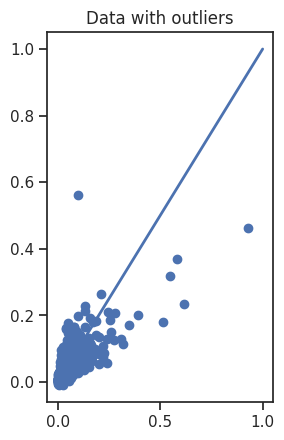

In [30]:
plt.figure(1)
plt.subplot(121)
plt.scatter(Resp_test, y_predKM)
plt.plot([0,1],[0,1], linewidth=2)
plt.title("Data with outliers")

Text(0.5, 1.0, 'Data without outliers')

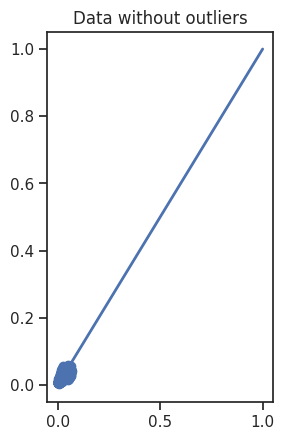

In [31]:
plt.subplot(122)
plt.scatter(Resp_test2, Y_predKM2)
plt.plot([0,1],[0,1], linewidth=2)
plt.title("Data without outliers")